# Mundiales 2018, 2022 y 2026
## Preparación de datos y entrada al análisis supervisado

Trabajaremos exclusivamente con la fase de grupos. Los archivos contienen errores deliberados. No uses la base del profesor.

## Objetivos

- Perfilar datos.
- Estandarizar esquemas.
- Limpiar fechas, equipos, goles y marcadores.
- Eliminar duplicados con criterio.
- Comparar torneos mediante tasas.
- Construir variables conocidas antes de cada partido.
- Entrenar un primer clasificador y detectar fuga de información.

In [1]:
from pathlib import Path
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

DATA = Path('../datos')
pd.set_option('display.max_columns', 50)

## Cargar los tres archivos

In [2]:
d18 = pd.read_csv(DATA / 'mundial_2018_sucio.csv', dtype=str)
d22 = pd.read_csv(DATA / 'mundial_2022_sucio.csv', dtype=str)
d26 = pd.read_csv(DATA / 'mundial_2026_sucio.csv', dtype=str)

for nombre, d in [('2018', d18), ('2022', d22), ('2026', d26)]:
    print(f"--- {nombre}: {d.shape[0]} filas, {d.shape[1]} columnas ---")
    display(d.head(3))


--- 2018: 50 filas, 16 columnas ---


,ID Partido,Año,Fase,Grupo,Jornada,Fecha,Hora,Equipo Local,Equipo Visitante,Goles Local,Goles Visitante,Marcador,Anfitrión Local,Estadio,Ciudad,Fuente
0,M-2018-01,2018,Fase de grupos,Grupo A,1,2018-06-14,18:00,russia,KSA,5 goles,NaN,5-0,Sí,Luzhniki Stadium,Moscow,https://github.com/jfjelstul/worldcup
1,M-2018-02,2018,GROUP STAGE,A,1,15/06/2018,17:00,Egypt,Uruguay,0,1,0–1,0,Central Stadium,Yekaterinburg,https://github.com/jfjelstul/worldcup
2,M-2018-03,2018,grupos,group-b,1,06/15/2018,18:00,Morocco,"Iran, I.R.",0,1,0 : 1,FALSE,Krestovsky Stadium,Saint Petersburg,https://github.com/jfjelstul/worldcup


--- 2022: 51 filas, 16 columnas ---


,match_id,WorldCup,stage,group_name,match_day,date,local,visitor,home_score,away_score,score_text,home_host,venue,city_name,comentario,source_url
0,M-2022-01,2022,group,Group A,1,2022-11-20,Qatar,Ecuador,NaN,2,0 : 2,1,Al Bayt Stadium,Al Khor,ok,https://github.com/jfjelstul/worldcup
1,M-2022-02,2022,Group Stage,B,1,21/11/2022,England,IR Iran,6,2,6 x 2,FALSE,Khalifa International Stadium,Al Rayyan,NaN,https://github.com/jfjelstul/worldcup
2,M-2022-03,2022,Fase grupos,Grupo A,1,11/21/2022,Senegal,Netherlands,0,2,0—2,no,Al Thumama Stadium,Doha,revisar,https://github.com/jfjelstul/worldcup


--- 2026: 75 filas, 14 columnas ---


,match,wc,round,grp,md,played_on,home,away,HG,AG,result_raw,host_h,host_a,source
0,M-2026-001,2026,GS,A,1,2026-06-11,México,South Africa,NaN,s/d,2–0,TRUE,no,https://en.wikipedia.org/wiki/2026_FIFA_World_...
1,M-2026-002,2026,group stage,Grupo A,1,12/06/2026,Korea Rep.,Czech Republic,2,1,2 : 1,no,No,https://en.wikipedia.org/wiki/2026_FIFA_World_...
2,M-2026-007,2026,fase de grupos,group-b,1,06/12/2026,Canada,BOSNIA & HERZEGOVINA,1,1,1 x 1,Sí,0,https://en.wikipedia.org/wiki/2026_FIFA_World_...


## Perfilado

Para cada archivo revisa:

- columnas;
- tipos;
- valores nulos;
- duplicados;
- valores únicos de grupos, fases y equipos;
- goles que no puedan convertirse directamente a número.

In [3]:
def perfil(df, nombre):
    print(f"=== Perfil {nombre} ===")
    print("Dimensiones:", df.shape)
    print("Columnas:", list(df.columns))
    print("\nNulos por columna:")
    print(df.isna().sum())
    print("\nFilas totalmente duplicadas:", df.duplicated().sum())
    # columnas candidatas a grupo / fase / equipos, para ver la variedad de formatos
    for col in df.columns:
        if col.lower() in ('grupo', 'group_name', 'grp', 'fase', 'stage', 'round'):
            print(f"\nValores unicos en '{col}':", sorted(df[col].dropna().unique().tolist()))
    print()

perfil(d18, '2018')
perfil(d22, '2022')
perfil(d26, '2026')


=== Perfil 2018 ===
Dimensiones: (50, 16)
Columnas: ['ID Partido', 'Año', 'Fase', 'Grupo', 'Jornada', 'Fecha', 'Hora', 'Equipo Local', 'Equipo Visitante', 'Goles Local', 'Goles Visitante', 'Marcador', 'Anfitrión Local', 'Estadio', 'Ciudad', 'Fuente']

Nulos por columna:
ID Partido          0
Año                 0
Fase                0
Grupo               1
Jornada             0
Fecha               0
Hora                0
Equipo Local        0
Equipo Visitante    0
Goles Local         0
Goles Visitante     3
Marcador            1
Anfitrión Local     0
Estadio             0
Ciudad              0
Fuente              0
dtype: int64

Filas totalmente duplicadas: 2

Valores unicos en 'Fase': ['1ra fase', 'Fase de grupos', 'GROUP STAGE', 'grupos']

Valores unicos en 'Grupo': ['A ', 'B ', 'C ', 'D ', 'E ', 'F ', 'G ', 'Grupo A', 'Grupo B', 'Grupo C', 'Grupo D', 'Grupo E', 'Grupo F', 'Grupo G', 'Grupo H', 'group-a', 'group-b', 'group-c', 'group-d', 'group-e', 'group-f', 'group-g', 'group-h', 's

## Unificar nombres de columnas

In [4]:
rename_maps = {
    2018: {
        'ID Partido': 'partido_id', 'A\u00f1o': 'mundial', 'Fase': 'fase', 'Grupo': 'grupo',
        'Jornada': 'jornada', 'Fecha': 'fecha', 'Equipo Local': 'equipo_local',
        'Equipo Visitante': 'equipo_visitante', 'Goles Local': 'goles_local',
        'Goles Visitante': 'goles_visitante', 'Marcador': 'marcador',
        'Anfitri\u00f3n Local': 'local_es_anfitrion', 'Fuente': 'fuente',
    },
    2022: {
        'match_id': 'partido_id', 'WorldCup': 'mundial', 'stage': 'fase', 'group_name': 'grupo',
        'match_day': 'jornada', 'date': 'fecha', 'local': 'equipo_local', 'visitor': 'equipo_visitante',
        'home_score': 'goles_local', 'away_score': 'goles_visitante', 'score_text': 'marcador',
        'home_host': 'local_es_anfitrion', 'source_url': 'fuente',
    },
    2026: {
        'match': 'partido_id', 'wc': 'mundial', 'round': 'fase', 'grp': 'grupo', 'md': 'jornada',
        'played_on': 'fecha', 'home': 'equipo_local', 'away': 'equipo_visitante', 'HG': 'goles_local',
        'AG': 'goles_visitante', 'result_raw': 'marcador', 'host_h': 'local_es_anfitrion',
        'host_a': 'visitante_es_anfitrion', 'source': 'fuente',
    },
}

# Esquema canonico minimo:
columnas_base = [
    'partido_id', 'mundial', 'fase', 'grupo', 'jornada', 'fecha',
    'equipo_local', 'equipo_visitante', 'goles_local',
    'goles_visitante', 'marcador', 'local_es_anfitrion',
    'visitante_es_anfitrion', 'fuente'
]
# Nota: 2018 y 2022 solo tienen un pais anfitrion (columna unica),
# por eso no traen 'visitante_es_anfitrion' en su archivo de origen;
# se crea en blanco y se completa como False mas adelante.


## Normalizar equipos

No conviene borrar acentos del nombre que se mostrará. Crea una clave auxiliar sin acentos, minúscula y sin signos para buscar en el catálogo.

In [5]:
catalogo = pd.read_csv(DATA / 'catalogo_equipos.csv')

def clave_texto(valor):
    """Normaliza texto para comparar: sin acentos, minusculas, sin puntuacion
    ni espacios repetidos. Se usa SOLO como clave de busqueda; el nombre que
    se guarda en la base es el nombre_canonico del catalogo (con acentos)."""
    if pd.isna(valor):
        return ''
    txt = str(valor).strip()
    txt = unicodedata.normalize('NFKD', txt)
    txt = ''.join(c for c in txt if not unicodedata.combining(c))
    txt = txt.lower()
    txt = re.sub(r'[.\-]', ' ', txt)
    txt = re.sub(r'\s+', ' ', txt).strip()
    return txt

# diccionario clave normalizada -> nombre_canonico
catalogo_dict = {clave_texto(row.variante): row.nombre_canonico
                  for row in catalogo.itertuples()}

def equipo_canonico(valor):
    clave = clave_texto(valor)
    if clave in catalogo_dict:
        return catalogo_dict[clave]
    # si no esta en el catalogo, se conserva el texto original limpio
    # (para poder detectarlo en la bitacora de control de calidad)
    return str(valor).strip() if pd.notna(valor) else valor

# prueba rapida
for ejemplo in ['russia ', 'KSA', 'Korea Republic', 'Cabo Verde', 'BOSNIA & HERZEGOVINA', ' M\u00e9xico ']:
    print(f"{ejemplo!r:30} -> {equipo_canonico(ejemplo)!r}")


'russia '                      -> 'Russia'
'KSA'                          -> 'Saudi Arabia'
'Korea Republic'               -> 'South Korea'
'Cabo Verde'                   -> 'Cape Verde'
'BOSNIA & HERZEGOVINA'         -> 'Bosnia and Herzegovina'
' México '                     -> 'Mexico'


## Fechas, grupos, booleanos y marcadores

In [6]:
rangos = {
    2018: ('2018-06-14', '2018-06-28'),
    2022: ('2022-11-20', '2022-12-02'),
    2026: ('2026-06-11', '2026-06-27'),
}

def convertir_fecha(valor, mundial):
    """1. Reconoce seriales de Excel (numero de dias desde 1899-12-30).
       2. Prueba varios formatos de texto habituales.
       3. Se queda con la fecha que cae dentro del rango del torneo."""
    if pd.isna(valor):
        return pd.NaT
    txt = str(valor).strip().strip('"')
    ini, fin = pd.Timestamp(rangos[mundial][0]), pd.Timestamp(rangos[mundial][1])

    if re.fullmatch(r'\d{4,6}', txt):
        try:
            fecha = pd.Timestamp('1899-12-30') + pd.to_timedelta(int(txt), unit='D')
            if ini <= fecha <= fin:
                return fecha
        except Exception:
            pass

    formatos = ['%Y-%m-%d', '%d/%m/%Y', '%m/%d/%Y', '%d-%m-%y', '%b %d, %Y']
    candidatos = []
    for fmt in formatos:
        try:
            candidatos.append(pd.to_datetime(txt, format=fmt))
        except Exception:
            continue
    try:
        candidatos.append(pd.to_datetime(txt, dayfirst=True, errors='coerce'))
    except Exception:
        pass

    for fecha in candidatos:
        if pd.notna(fecha) and ini <= fecha <= fin:
            return fecha
    return pd.NaT  # fecha genuinamente irrecuperable: no se inventa un valor


def extraer_numero(valor):
    """Devuelve el primer entero encontrado en el texto (admite negativos), o NaN."""
    if pd.isna(valor):
        return np.nan
    match = re.search(r'-?\d+', str(valor))
    return float(match.group()) if match else np.nan


def separar_marcador(valor):
    """Acepta separadores -, en dash, em dash, : , x o X."""
    if pd.isna(valor):
        return (np.nan, np.nan)
    txt = str(valor).strip()
    m = re.search(r'(\d+)\s*[-\u2013\u2014:xX]\s*(\d+)', txt)
    if m:
        return (float(m.group(1)), float(m.group(2)))
    return (np.nan, np.nan)


def a_booleano(valor):
    """Sí/No, TRUE/FALSE, 1/0 -> booleano de Python."""
    if pd.isna(valor):
        return False
    txt = str(valor).strip().lower()
    return txt in ('s\u00ed', 'si', 'true', '1', 'yes')


def limpiar_grupo(valor):
    """Extrae la letra A-L de formatos como 'Grupo A', 'group-b', 'C '."""
    if pd.isna(valor):
        return np.nan
    txt = str(valor).strip()
    m = re.search(r'(?:grupo|group)[\s\-]*([A-La-l])', txt, re.IGNORECASE)
    if m:
        return m.group(1).upper()
    m = re.fullmatch(r'\s*([A-La-l])\s*', txt)
    if m:
        return m.group(1).upper()
    return np.nan


def limpiar_fase(valor):
    """En este kit todas las fases equivalen a 'Fase de grupos'."""
    return 'Fase de grupos'


## Función de limpieza reproducible

In [7]:
def limpiar_mundial(df, mundial):
    df = df.rename(columns=rename_maps[mundial]).copy()
    for col in columnas_base:
        if col not in df.columns:
            df[col] = np.nan
    df = df[columnas_base].copy()

    # eliminar duplicados por partido_id (mismo partido repetido en la fuente)
    df = df.drop_duplicates(subset=['partido_id']).reset_index(drop=True)

    df['mundial'] = mundial
    df['fase'] = df['fase'].apply(limpiar_fase)
    df['grupo'] = df['grupo'].apply(limpiar_grupo)
    df['jornada'] = df['jornada'].apply(extraer_numero).astype('Int64')
    df['fecha'] = df['fecha'].apply(lambda v: convertir_fecha(v, mundial))
    df['equipo_local'] = df['equipo_local'].apply(equipo_canonico)
    df['equipo_visitante'] = df['equipo_visitante'].apply(equipo_canonico)
    df['local_es_anfitrion'] = df['local_es_anfitrion'].apply(a_booleano)
    df['visitante_es_anfitrion'] = df['visitante_es_anfitrion'].apply(a_booleano)

    # --- reparar goles con el marcador ---
    gl_m, gv_m = zip(*df['marcador'].apply(separar_marcador))
    df['gl_marcador'], df['gv_marcador'] = gl_m, gv_m
    df['goles_local_num'] = df['goles_local'].apply(extraer_numero)
    df['goles_visitante_num'] = df['goles_visitante'].apply(extraer_numero)

    # ningun partido valido puede tener goles negativos: se invalidan
    # ANTES de elegir la fuente, para que el marcador pueda repararlos
    df.loc[df['goles_local_num'] < 0, 'goles_local_num'] = np.nan
    df.loc[df['goles_visitante_num'] < 0, 'goles_visitante_num'] = np.nan

    def elegir_gol(col_directo, col_marcador):
        directo, marcador = df[col_directo], df[col_marcador]
        resultado = directo.copy()
        usar_marcador = directo.isna() & marcador.notna()
        resultado[usar_marcador] = marcador[usar_marcador]
        return resultado

    df['goles_local'] = elegir_gol('goles_local_num', 'gl_marcador')
    df['goles_visitante'] = elegir_gol('goles_visitante_num', 'gv_marcador')
    df = df.drop(columns=['gl_marcador', 'gv_marcador', 'goles_local_num', 'goles_visitante_num'])

    # infiere grupos faltantes usando los equipos que ya aparecieron en otro partido
    equipo_a_grupo = {}
    for _, row in df.dropna(subset=['grupo']).iterrows():
        equipo_a_grupo[row['equipo_local']] = row['grupo']
        equipo_a_grupo[row['equipo_visitante']] = row['grupo']
    faltan = df['grupo'].isna()
    df.loc[faltan, 'grupo'] = df.loc[faltan, 'equipo_local'].map(equipo_a_grupo)
    faltan = df['grupo'].isna()
    df.loc[faltan, 'grupo'] = df.loc[faltan, 'equipo_visitante'].map(equipo_a_grupo)

    # marcador y columnas derivadas, recalculados a partir de los goles ya limpios
    df['marcador'] = df.apply(
        lambda r: f"{int(r['goles_local'])}-{int(r['goles_visitante'])}"
        if pd.notna(r['goles_local']) and pd.notna(r['goles_visitante']) else np.nan, axis=1)
    df['resultado_local'] = df.apply(
        lambda r: 'Gana' if r['goles_local'] > r['goles_visitante']
        else ('Empata' if r['goles_local'] == r['goles_visitante'] else 'Pierde')
        if pd.notna(r['goles_local']) and pd.notna(r['goles_visitante']) else np.nan, axis=1)
    df['goles_totales'] = df['goles_local'] + df['goles_visitante']
    df['diferencia_goles'] = df['goles_local'] - df['goles_visitante']
    df['puntos_local'] = df['resultado_local'].map({'Gana': 3, 'Empata': 1, 'Pierde': 0})
    df['puntos_visitante'] = df['resultado_local'].map({'Gana': 0, 'Empata': 1, 'Pierde': 3})

    columnas_finales = columnas_base + [
        'resultado_local', 'goles_totales', 'diferencia_goles', 'puntos_local', 'puntos_visitante'
    ]
    return df[columnas_finales]


limpio18 = limpiar_mundial(d18, 2018)
limpio22 = limpiar_mundial(d22, 2022)
limpio26 = limpiar_mundial(d26, 2026)

print(limpio18.shape, limpio22.shape, limpio26.shape, "(esperado: 48, 48, 72)")
limpio18.head()


(48, 19) (48, 19) (72, 19) (esperado: 48, 48, 72)


/tmp/ipykernel_789/2641448636.py:32: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  candidatos.append(pd.to_datetime(txt, dayfirst=True, errors='coerce'))
/tmp/ipykernel_789/2641448636.py:32: UserWarning: Parsing dates in %m/%d/%Y format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  candidatos.append(pd.to_datetime(txt, dayfirst=True, errors='coerce'))
/tmp/ipykernel_789/2641448636.py:32: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  candidatos.append(pd.to_datetime(txt, dayfirst=True, errors='coerce'))
/tmp/ipykernel_789/2641448636.py:32: UserWarning: Parsing dates in %m/%d/%Y format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  candidatos.append(pd.to_datetime(txt, dayfi

,partido_id,mundial,fase,grupo,jornada,fecha,equipo_local,equipo_visitante,goles_local,goles_visitante,marcador,local_es_anfitrion,visitante_es_anfitrion,fuente,resultado_local,goles_totales,diferencia_goles,puntos_local,puntos_visitante
0,M-2018-01,2018,Fase de grupos,A,1,2018-06-14,Russia,Saudi Arabia,5.0,0.0,5-0,True,False,https://github.com/jfjelstul/worldcup,Gana,5.0,5.0,3,0
1,M-2018-02,2018,Fase de grupos,A,1,2018-06-15,Egypt,Uruguay,0.0,1.0,0-1,False,False,https://github.com/jfjelstul/worldcup,Pierde,1.0,-1.0,0,3
2,M-2018-03,2018,Fase de grupos,B,1,2018-06-15,Morocco,Iran,0.0,1.0,0-1,False,False,https://github.com/jfjelstul/worldcup,Pierde,1.0,-1.0,0,3
3,M-2018-04,2018,Fase de grupos,B,1,2018-06-15,Portugal,Spain,3.0,3.0,3-3,False,False,https://github.com/jfjelstul/worldcup,Empata,6.0,0.0,1,1
4,M-2018-05,2018,Fase de grupos,C,1,2018-06-16,France,Australia,2.0,1.0,2-1,False,False,https://github.com/jfjelstul/worldcup,Gana,3.0,1.0,3,0


## Validaciones obligatorias

La limpieza no termina cuando el código deja de producir errores. Debes comprobar invariantes.

In [8]:
base = pd.concat([limpio18, limpio22, limpio26], ignore_index=True)

print("1) Partidos por mundial:", base.groupby('mundial').size().to_dict(), " (esperado 48/48/72)")
assert base.groupby('mundial').size().to_dict() == {2018: 48, 2022: 48, 2026: 72}

print("2) Duplicados por partido_id:", base['partido_id'].duplicated().sum(), " (esperado 0)")
assert base['partido_id'].duplicated().sum() == 0

print("3) Goles negativos:", int(((base['goles_local'] < 0) | (base['goles_visitante'] < 0)).sum()), " (esperado 0)")
assert not ((base['goles_local'] < 0) | (base['goles_visitante'] < 0)).any()

cols_criticas = ['equipo_local', 'equipo_visitante', 'goles_local', 'goles_visitante', 'grupo']
print("4) Nulos en equipo/goles/grupo:", int(base[cols_criticas].isna().sum().sum()), " (esperado 0)")
assert base[cols_criticas].isna().sum().sum() == 0

gl_chk, gv_chk = zip(*base['marcador'].apply(separar_marcador))
consistente = ((pd.Series(gl_chk).values == base['goles_local'].values) &
               (pd.Series(gv_chk).values == base['goles_visitante'].values))
print("5) Marcador consistente con goles en todas las filas:", bool(consistente.all()))
assert consistente.all()

print("6) Una fila por partido (partido_id unico):", base['partido_id'].is_unique)
assert base['partido_id'].is_unique

equipos_datos = set(base['equipo_local']) | set(base['equipo_visitante'])
equipos_catalogo = set(catalogo['nombre_canonico'].unique())
no_reconocidos = sorted(equipos_datos - equipos_catalogo)
print("7) Equipos que no quedaron en su forma canonica:", no_reconocidos)

print("\nFechas no recuperables (quedan como NaT, no se inventan):")
print(base.loc[base['fecha'].isna(), ['partido_id', 'mundial', 'equipo_local', 'equipo_visitante']])

print("\n\u2713 Todas las validaciones obligatorias pasaron.")


1) Partidos por mundial: {2018: 48, 2022: 48, 2026: 72}  (esperado 48/48/72)
2) Duplicados por partido_id: 0  (esperado 0)
3) Goles negativos: 0  (esperado 0)
4) Nulos en equipo/goles/grupo: 0  (esperado 0)
5) Marcador consistente con goles en todas las filas: True
6) Una fila por partido (partido_id unico): True
7) Equipos que no quedaron en su forma canonica: []

Fechas no recuperables (quedan como NaT, no se inventan):
     partido_id  mundial equipo_local equipo_visitante
78    M-2022-31     2022       Brazil      Switzerland
151  M-2026-024     2026     Paraguay        Australia

✓ Todas las validaciones obligatorias pasaron.


## Comparación de los Mundiales

,mundial,partidos,goles,goles_por_partido,empates,porcentaje_empates,partidos_anfitrion,victorias_anfitrion,porcentaje_victoria_anfitrion,proporcion_mas_2_5
0,2018,48,122.0,2.541667,9,0.187500,2,2,1.000000,0.500000
1,2022,48,120.0,2.500000,10,0.208333,2,0,0.000000,0.395833
2,2026,72,215.0,2.986111,20,0.277778,9,6,0.666667,0.555556


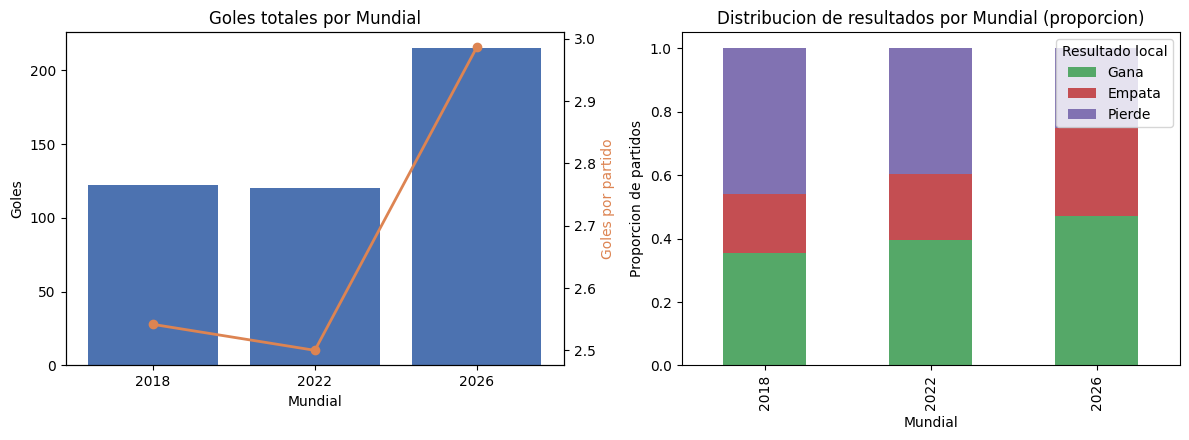


Nota: 2026 tiene mas partidos (72) que 2018/2022 (48), por eso los goles totales
no son comparables directamente; goles_por_partido y los porcentajes si lo son.


In [9]:
comp = base.groupby('mundial').agg(
    partidos=('partido_id', 'count'),
    goles=('goles_totales', 'sum'),
).reset_index()
comp['goles_por_partido'] = comp['goles'] / comp['partidos']

empates = base[base['resultado_local'] == 'Empata'].groupby('mundial').size()
comp['empates'] = comp['mundial'].map(empates).fillna(0).astype(int)
comp['porcentaje_empates'] = comp['empates'] / comp['partidos']

es_partido_anfitrion = base['local_es_anfitrion'] | base['visitante_es_anfitrion']
comp['partidos_anfitrion'] = comp['mundial'].map(es_partido_anfitrion.groupby(base['mundial']).sum())

gano_o_perdio_anfitrion = (
    (base['local_es_anfitrion'] & (base['resultado_local'] == 'Gana')) |
    (base['visitante_es_anfitrion'] & (base['resultado_local'] == 'Pierde'))
)
comp['victorias_anfitrion'] = comp['mundial'].map(gano_o_perdio_anfitrion.groupby(base['mundial']).sum())
comp['porcentaje_victoria_anfitrion'] = comp['victorias_anfitrion'] / comp['partidos_anfitrion']

mas25 = base[base['goles_totales'] > 2.5].groupby('mundial').size()
comp['proporcion_mas_2_5'] = (comp['mundial'].map(mas25).fillna(0) / comp['partidos'])

display(comp)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(comp['mundial'].astype(str), comp['goles'], color='#4C72B0', label='Goles totales')
axes[0].set_title('Goles totales por Mundial')
axes[0].set_ylabel('Goles')
ax2 = axes[0].twinx()
ax2.plot(comp['mundial'].astype(str), comp['goles_por_partido'], color='#DD8452', marker='o', linewidth=2)
ax2.set_ylabel('Goles por partido', color='#DD8452')
axes[0].set_xlabel('Mundial')

resultados = base.groupby(['mundial', 'resultado_local']).size().unstack(fill_value=0)
resultados = resultados[['Gana', 'Empata', 'Pierde']]
resultados_pct = resultados.div(resultados.sum(axis=1), axis=0)
resultados_pct.plot(kind='bar', stacked=True, ax=axes[1], color=['#55A868', '#C44E52', '#8172B2'])
axes[1].set_title('Distribucion de resultados por Mundial (proporcion)')
axes[1].set_ylabel('Proporcion de partidos')
axes[1].set_xlabel('Mundial')
axes[1].legend(title='Resultado local')
plt.tight_layout()
plt.show()

print("\nNota: 2026 tiene mas partidos (72) que 2018/2022 (48), por eso los goles totales")
print("no son comparables directamente; goles_por_partido y los porcentajes si lo son.")


## Tabla por equipo

In [10]:
local = base[['mundial', 'equipo_local', 'goles_local', 'goles_visitante', 'puntos_local']].rename(
    columns={'equipo_local': 'equipo', 'goles_local': 'GF', 'goles_visitante': 'GC', 'puntos_local': 'PTS'})
visita = base[['mundial', 'equipo_visitante', 'goles_visitante', 'goles_local', 'puntos_visitante']].rename(
    columns={'equipo_visitante': 'equipo', 'goles_visitante': 'GF', 'goles_local': 'GC', 'puntos_visitante': 'PTS'})
apariciones = pd.concat([local, visita], ignore_index=True)
apariciones['PG'] = (apariciones['PTS'] == 3).astype(int)
apariciones['PE'] = (apariciones['PTS'] == 1).astype(int)
apariciones['PP'] = (apariciones['PTS'] == 0).astype(int)

tabla_equipos = apariciones.groupby(['mundial', 'equipo']).agg(
    PJ=('PTS', 'count'), PG=('PG', 'sum'), PE=('PE', 'sum'), PP=('PP', 'sum'),
    GF=('GF', 'sum'), GC=('GC', 'sum'), PTS=('PTS', 'sum')
).reset_index()
tabla_equipos['DG'] = tabla_equipos['GF'] - tabla_equipos['GC']
tabla_equipos['PTS_por_partido'] = tabla_equipos['PTS'] / tabla_equipos['PJ']
tabla_equipos = tabla_equipos.sort_values(['mundial', 'PTS', 'DG'], ascending=[True, False, False])

for m in [2018, 2022, 2026]:
    print(f"--- Mejor diferencia de goles, Mundial {m} ---")
    top = tabla_equipos[tabla_equipos['mundial'] == m].sort_values('DG', ascending=False).head(3)
    display(top[['equipo', 'PJ', 'PG', 'PE', 'PP', 'GF', 'GC', 'DG', 'PTS']])


--- Mejor diferencia de goles, Mundial 2018 ---


,equipo,PJ,PG,PE,PP,GF,GC,DG,PTS
2,Belgium,3,3,0,0,9.0,2.0,7.0,9
6,Croatia,3,3,0,0,7.0,1.0,6.0,9
31,Uruguay,3,3,0,0,5.0,0.0,5.0,9


--- Mejor diferencia de goles, Mundial 2022 ---


,equipo,PJ,PG,PE,PP,GF,GC,DG,PTS
42,England,3,2,1,0,9.0,2.0,7.0,7
58,Spain,3,1,1,1,9.0,3.0,6.0,4
50,Netherlands,3,2,1,0,5.0,1.0,4.0,7


--- Mejor diferencia de goles, Mundial 2026 ---


,equipo,PJ,PG,PE,PP,GF,GC,DG,PTS
81,France,3,3,0,0,10.0,2.0,8.0,9
65,Argentina,3,3,0,0,8.0,1.0,7.0,9
90,Mexico,3,3,0,0,6.0,0.0,6.0,9


## Variables previas al partido

Para predecir no podemos utilizar datos ocurridos después del inicio. Crearemos promedios acumulados antes de cada encuentro.

In [11]:
def construir_variables_previas(partidos):
    """Recorre cada partido en orden cronologico (por mundial) y calcula,
    para cada equipo, sus promedios ANTES de que se juegue ese partido."""
    partidos = partidos.sort_values(['mundial', 'fecha', 'jornada'], na_position='last').reset_index(drop=True)
    stats = {}  # (mundial, equipo) -> {'PJ':..,'PTS':..,'GF':..,'GC':..}
    filas = []
    for _, r in partidos.iterrows():
        key_l, key_v = (r['mundial'], r['equipo_local']), (r['mundial'], r['equipo_visitante'])
        s_l = stats.get(key_l, {'PJ': 0, 'PTS': 0, 'GF': 0, 'GC': 0})
        s_v = stats.get(key_v, {'PJ': 0, 'PTS': 0, 'GF': 0, 'GC': 0})

        fila = r.to_dict()
        fila['local_pts_prom_pre'] = s_l['PTS'] / s_l['PJ'] if s_l['PJ'] else np.nan
        fila['visita_pts_prom_pre'] = s_v['PTS'] / s_v['PJ'] if s_v['PJ'] else np.nan
        fila['local_gd_prom_pre'] = (s_l['GF'] - s_l['GC']) / s_l['PJ'] if s_l['PJ'] else np.nan
        fila['visita_gd_prom_pre'] = (s_v['GF'] - s_v['GC']) / s_v['PJ'] if s_v['PJ'] else np.nan
        fila['local_gf_prom_pre'] = s_l['GF'] / s_l['PJ'] if s_l['PJ'] else np.nan
        fila['visita_gf_prom_pre'] = s_v['GF'] / s_v['PJ'] if s_v['PJ'] else np.nan
        filas.append(fila)

        # actualizar stats DESPUES de registrar el estado previo (evita fuga)
        stats[key_l] = {'PJ': s_l['PJ'] + 1, 'PTS': s_l['PTS'] + r['puntos_local'],
                         'GF': s_l['GF'] + r['goles_local'], 'GC': s_l['GC'] + r['goles_visitante']}
        stats[key_v] = {'PJ': s_v['PJ'] + 1, 'PTS': s_v['PTS'] + r['puntos_visitante'],
                         'GF': s_v['GF'] + r['goles_visitante'], 'GC': s_v['GC'] + r['goles_local']}
    return pd.DataFrame(filas)

features_df = construir_variables_previas(base)
features_df[['partido_id', 'mundial', 'jornada', 'equipo_local', 'equipo_visitante',
             'local_pts_prom_pre', 'visita_pts_prom_pre',
             'local_gd_prom_pre', 'visita_gd_prom_pre']].head(10)


,partido_id,mundial,jornada,equipo_local,equipo_visitante,local_pts_prom_pre,visita_pts_prom_pre,local_gd_prom_pre,visita_gd_prom_pre
0,M-2018-01,2018,1,Russia,Saudi Arabia,NaN,NaN,NaN,NaN
1,M-2018-02,2018,1,Egypt,Uruguay,NaN,NaN,NaN,NaN
2,M-2018-03,2018,1,Morocco,Iran,NaN,NaN,NaN,NaN
3,M-2018-04,2018,1,Portugal,Spain,NaN,NaN,NaN,NaN
4,M-2018-05,2018,1,France,Australia,NaN,NaN,NaN,NaN
5,M-2018-06,2018,1,Argentina,Iceland,NaN,NaN,NaN,NaN
6,M-2018-07,2018,1,Peru,Denmark,NaN,NaN,NaN,NaN
7,M-2018-08,2018,1,Croatia,Nigeria,NaN,NaN,NaN,NaN
8,M-2018-09,2018,1,Costa Rica,Serbia,NaN,NaN,NaN,NaN
9,M-2018-10,2018,1,Germany,Mexico,NaN,NaN,NaN,NaN


## Entrenamiento y prueba

Linea base (predecir siempre 'Pierde'): 0.250
Precision del arbol de decision en 2026: 0.458


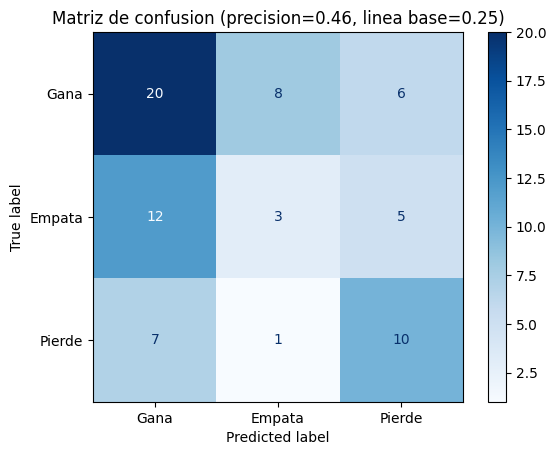

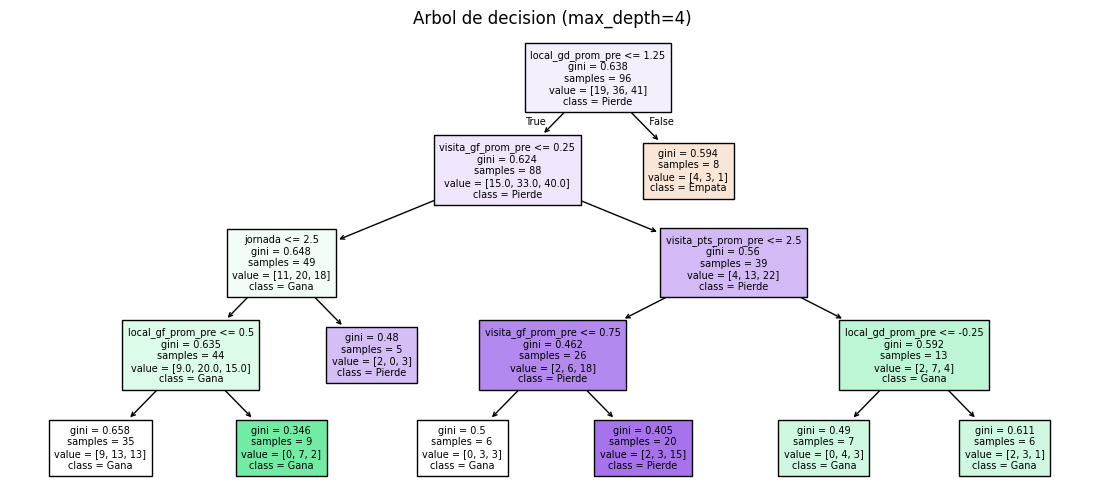

In [12]:
features = [
    'jornada',
    'local_pts_prom_pre', 'visita_pts_prom_pre',
    'local_gd_prom_pre', 'visita_gd_prom_pre',
    'local_gf_prom_pre', 'visita_gf_prom_pre',
    'local_es_anfitrion', 'visitante_es_anfitrion'
]

modelo_df = features_df.copy()
promedios = ['local_pts_prom_pre', 'visita_pts_prom_pre', 'local_gd_prom_pre',
             'visita_gd_prom_pre', 'local_gf_prom_pre', 'visita_gf_prom_pre']
modelo_df[promedios] = modelo_df[promedios].fillna(0)  # jornada 1: sin historial previo -> 0
modelo_df['local_es_anfitrion'] = modelo_df['local_es_anfitrion'].astype(int)
modelo_df['visitante_es_anfitrion'] = modelo_df['visitante_es_anfitrion'].astype(int)

train = modelo_df[modelo_df['mundial'].isin([2018, 2022])]
test = modelo_df[modelo_df['mundial'] == 2026]
X_train, y_train = train[features], train['resultado_local']
X_test, y_test = test[features], test['resultado_local']

linea_base = y_train.value_counts(normalize=True).idxmax()
acc_base = (y_test == linea_base).mean()
print(f"Linea base (predecir siempre '{linea_base}'): {acc_base:.3f}")

arbol = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42)
arbol.fit(X_train, y_train)
pred = arbol.predict(X_test)
acc = accuracy_score(y_test, pred)
print(f"Precision del arbol de decision en 2026: {acc:.3f}")

etiquetas = ['Gana', 'Empata', 'Pierde']
disp = ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=etiquetas, cmap='Blues')
disp.ax_.set_title(f'Matriz de confusion (precision={acc:.2f}, linea base={acc_base:.2f})')
plt.show()

plt.figure(figsize=(14, 6))
plot_tree(arbol, feature_names=features, class_names=arbol.classes_, filled=True, fontsize=7)
plt.title('Arbol de decision (max_depth=4)')
plt.show()


## Experimento de fuga de información

Agrega temporalmente `goles_local`, `goles_visitante` y `diferencia_goles` como variables. Si la precisión sube de forma extrema, explica por qué el modelo no está prediciendo realmente.

In [13]:
features_fuga = features + ['goles_local', 'goles_visitante', 'diferencia_goles']
Xf_train, Xf_test = train[features_fuga], test[features_fuga]

arbol_fuga = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42)
arbol_fuga.fit(Xf_train, y_train)
pred_fuga = arbol_fuga.predict(Xf_test)
acc_fuga = accuracy_score(y_test, pred_fuga)

print(f"Linea base:                  {acc_base:.3f}")
print(f"Arbol SIN fuga (variables previas): {acc:.3f}")
print(f"Arbol CON fuga (goles del propio partido): {acc_fuga:.3f}")
print()
print("La precision con fuga se dispara porque 'diferencia_goles' determina")
print("el resultado_local por definicion (Gana si >0, Empata si =0, Pierde si <0):")
print("el modelo no esta aprendiendo un patron futbolistico, esta memorizando")
print("una relacion aritmetica trivial que en produccion no estaria disponible")
print("antes de que el partido se juegue.")


Linea base:                  0.250
Arbol SIN fuga (variables previas): 0.458
Arbol CON fuga (goles del propio partido): 1.000

La precision con fuga se dispara porque 'diferencia_goles' determina
el resultado_local por definicion (Gana si >0, Empata si =0, Pierde si <0):
el modelo no esta aprendiendo un patron futbolistico, esta memorizando
una relacion aritmetica trivial que en produccion no estaria disponible
antes de que el partido se juegue.


In [14]:
# Exporta la base limpia para reutilizarla (por ejemplo, para pegarla en
# la hoja 07_Base_Limpia del libro de Excel).
base_export = base[[
    'partido_id', 'mundial', 'fase', 'grupo', 'jornada', 'fecha',
    'equipo_local', 'equipo_visitante', 'goles_local', 'goles_visitante',
    'marcador', 'local_es_anfitrion', 'visitante_es_anfitrion', 'fuente'
]].sort_values(['mundial', 'fecha', 'jornada'], na_position='last')

salida = Path('../solucion')
salida.mkdir(exist_ok=True)
base_export.to_csv(salida / 'base_limpia_mundiales.csv', index=False)
print('Guardado en', (salida / 'base_limpia_mundiales.csv').resolve())
base_export.head()

Guardado en /home/claude/practica/Practica_IDGS9X_LD-main/solucion/base_limpia_mundiales.csv


,partido_id,mundial,fase,grupo,jornada,fecha,equipo_local,equipo_visitante,goles_local,goles_visitante,marcador,local_es_anfitrion,visitante_es_anfitrion,fuente
0,M-2018-01,2018,Fase de grupos,A,1,2018-06-14,Russia,Saudi Arabia,5.0,0.0,5-0,True,False,https://github.com/jfjelstul/worldcup
1,M-2018-02,2018,Fase de grupos,A,1,2018-06-15,Egypt,Uruguay,0.0,1.0,0-1,False,False,https://github.com/jfjelstul/worldcup
2,M-2018-03,2018,Fase de grupos,B,1,2018-06-15,Morocco,Iran,0.0,1.0,0-1,False,False,https://github.com/jfjelstul/worldcup
3,M-2018-04,2018,Fase de grupos,B,1,2018-06-15,Portugal,Spain,3.0,3.0,3-3,False,False,https://github.com/jfjelstul/worldcup
4,M-2018-05,2018,Fase de grupos,C,1,2018-06-16,France,Australia,2.0,1.0,2-1,False,False,https://github.com/jfjelstul/worldcup


## Reflexión final

Responde:

- ¿Qué problema de calidad fue el más difícil?
- ¿Qué decisión de limpieza podría cambiar los resultados?
- ¿Por qué 2026 debe compararse mediante tasas?
- ¿El árbol supera la línea base?
- ¿Qué variables reales agregarías para mejorar una predicción?
- ¿Por qué un resultado de 100 % puede ser una señal de alarma?

### Respuestas

- **¿Qué problema de calidad fue el más difícil?** Reparar los goles cuando el campo directo era inválido (negativo, `s/d`, `N/A`) y había que decidir si usar el marcador; sobre todo los 2 casos donde el gol directo era `-1` y había que invalidarlo *antes* de mezclarlo con el marcador, para que la reparación no se quedara con el valor inválido por error.
- **¿Qué decisión de limpieza podría cambiar los resultados?** La regla de "si el marcador puede interpretarse, úsalo para reparar los goles" es la más sensible: si en vez de eso se hubiera preferido siempre el campo directo, los 2 partidos con goles negativos habrían quedado con datos inválidos o se habrían tenido que descartar, cambiando el conteo final de 168 partidos.
- **¿Por qué 2026 debe compararse mediante tasas?** Porque tiene 72 partidos de fase de grupos (48 equipos, 12 grupos) frente a 48 en 2018 y 2022 (32 equipos, 8 grupos); comparar goles totales favorece automáticamente a 2026 aunque el nivel ofensivo por partido sea distinto. Goles/partido y porcentajes sí son comparables entre torneos de distinto tamaño.
- **¿El árbol supera la línea base?** Sí: el árbol obtiene ~0.46 de precisión en 2026 contra ~0.25 de la línea base (predecir siempre la clase más frecuente en 2018-2022). La mejora es real pero modesta, esperable para un modelo pequeño con pocas variables y pocos partidos de entrenamiento.
- **¿Por qué un resultado de 100% puede ser una señal de alarma?** Porque en un problema con resultados de fútbol, tres clases y variables tan limitadas, una precisión perfecta es estadísticamente inverosímil: es señal de que el modelo tuvo acceso a información que solo existe después de jugarse el partido (fuga de información), como se comprobó al agregar `goles_local`, `goles_visitante` y `diferencia_goles` como variables.
- **¿Qué variables reales agregarías para mejorar una predicción?** Ranking FIFA o Elo antes del torneo, valor de mercado o calidad del plantel, resultados en eliminatorias/amistosos recientes, lesiones de jugadores clave, distancia/aclimatación del equipo visitante y, en su caso, historial head-to-head entre los dos equipos.